In [94]:
#from ucimlrepo import fetch_ucirepo, list_available_datasets
# fetch dataset 
#nursery = fetch_ucirepo(id=76) 

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
# Get full dataset (features + target together)
df = pd.read_csv('nursery.csv')

print(df.shape)
df


(12960, 9)


,parents,has_nurs,form,children,housing,finance,social,health,final evaluation
0,usual,proper,complete,1,convenient,convenient,nonprob,recommended,recommend
1,usual,proper,complete,1,convenient,convenient,nonprob,priority,priority
2,usual,proper,complete,1,convenient,convenient,nonprob,not_recom,not_recom
3,usual,proper,complete,1,convenient,convenient,slightly_prob,recommended,recommend
4,usual,proper,complete,1,convenient,convenient,slightly_prob,priority,priority
...,...,...,...,...,...,...,...,...,...
12955,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,priority,spec_prior
12956,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,not_recom,not_recom
12957,great_pret,very_crit,foster,more,critical,inconv,problematic,recommended,spec_prior
12958,great_pret,very_crit,foster,more,critical,inconv,problematic,priority,spec_prior


### EDA

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12960 entries, 0 to 12959
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   parents           12960 non-null  object
 1   has_nurs          12960 non-null  object
 2   form              12960 non-null  object
 3   children          12960 non-null  object
 4   housing           12960 non-null  object
 5   finance           12960 non-null  object
 6   social            12960 non-null  object
 7   health            12960 non-null  object
 8   final evaluation  12960 non-null  object
dtypes: object(9)
memory usage: 911.4+ KB


In [98]:
df.shape

(12960, 9)

In [99]:
### Check missing values
df.isnull().sum()

parents             0
has_nurs            0
form                0
children            0
housing             0
finance             0
social              0
health              0
final evaluation    0
dtype: int64

In [100]:
## Unique values per column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


parents: 3 unique values
has_nurs: 5 unique values
form: 4 unique values
children: 4 unique values
housing: 3 unique values
finance: 2 unique values
social: 3 unique values
health: 3 unique values
final evaluation: 5 unique values


In [101]:
df['final evaluation'].value_counts(normalize=True)


final evaluation
not_recom     0.333333
priority      0.329167
spec_prior    0.312037
very_recom    0.025309
recommend     0.000154
Name: proportion, dtype: float64

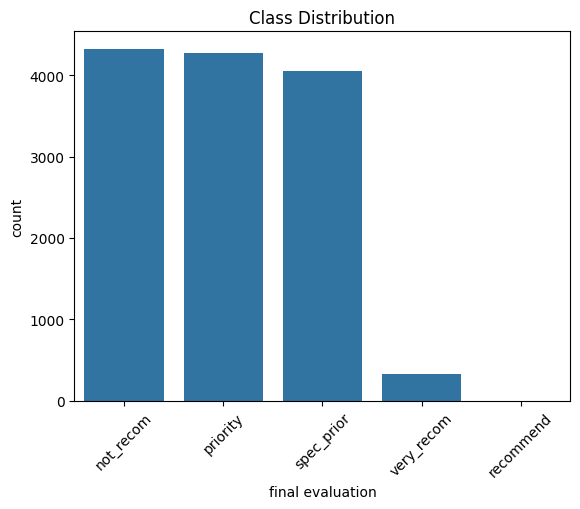

In [102]:
sns.countplot(data=df, x='final evaluation', order=df['final evaluation'].value_counts().index)
plt.title('Class Distribution')
plt.xticks(rotation=45)
plt.show()


In [103]:
df['final evaluation'] = df['final evaluation'].replace({'recommend': 'very_recom'}) # Merge recommend and very_recom

In [104]:
df['final evaluation'].value_counts(normalize=True)

final evaluation
not_recom     0.333333
priority      0.329167
spec_prior    0.312037
very_recom    0.025463
Name: proportion, dtype: float64

In [105]:
for col in df.columns:
    print(f"Column: {col}")
    print(f"Unique values ({df[col].nunique()}): {df[col].unique()}")
    print(df[col].value_counts())  # proportion of each category
    print("-"*40)


Column: parents
Unique values (3): ['usual' 'pretentious' 'great_pret']
parents
usual          4320
pretentious    4320
great_pret     4320
Name: count, dtype: int64
----------------------------------------
Column: has_nurs
Unique values (5): ['proper' 'less_proper' 'improper' 'critical' 'very_crit']
has_nurs
proper         2592
less_proper    2592
improper       2592
critical       2592
very_crit      2592
Name: count, dtype: int64
----------------------------------------
Column: form
Unique values (4): ['complete' 'completed' 'incomplete' 'foster']
form
complete      3240
completed     3240
incomplete    3240
foster        3240
Name: count, dtype: int64
----------------------------------------
Column: children
Unique values (4): ['1' '2' '3' 'more']
children
1       3240
2       3240
3       3240
more    3240
Name: count, dtype: int64
----------------------------------------
Column: housing
Unique values (3): ['convenient' 'less_conv' 'critical']
housing
convenient    4320
less_conv 

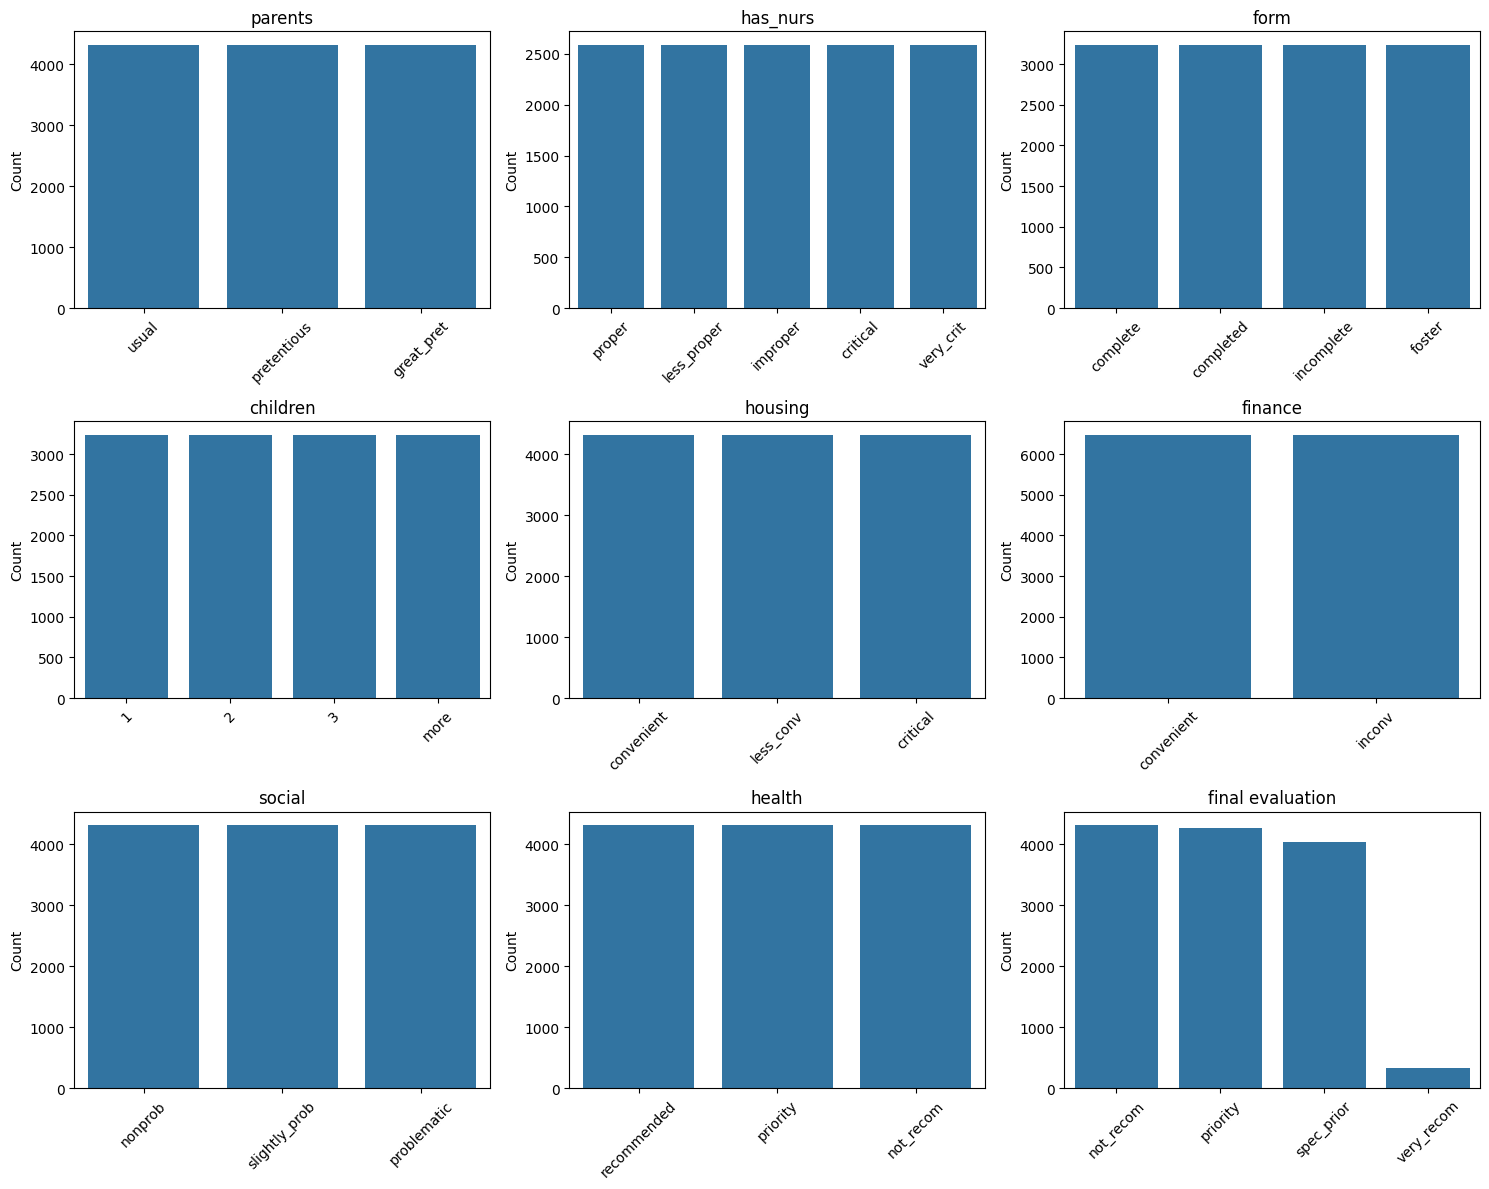

In [106]:
cols = df.columns
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))

for i, col in enumerate(cols):
    ax = axes[i // n_cols, i % n_cols]
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=ax)
    ax.set_title(f"{col}")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)

# Hide empty subplots if any
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()


In [107]:
# Train /test/validation split
from sklearn.model_selection import train_test_split
df_full_train , df_test = train_test_split(df, test_size = 0.2, random_state = 11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state =11)

In [108]:
df_train = df_train.reset_index(drop =True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [109]:
len(df_train), len(df_val), len(df_test)

(7776, 2592, 2592)

In [110]:
# Separate features and target
df_train_f = df_train.drop('final evaluation', axis=1)
df_val_f = df_val.drop('final evaluation', axis=1)
df_test_f = df_test.drop('final evaluation', axis=1)


In [111]:
len(df_train_f)

7776

In [112]:
y_train = df_train['final evaluation']
y_val = df_val['final evaluation']
y_test = df_test['final evaluation']

In [113]:
len(y_train)

7776

In [114]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

print(le.classes_)   # shows mapping like ['not_recom', 'priority', 'spec_prior', 'very_recom']


['not_recom' 'priority' 'spec_prior' 'very_recom']


In [115]:
len(y_train)

7776

### Decision Tress

In [116]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import roc_curve, auc

In [117]:
dv = DictVectorizer(sparse = False)
X_train = dv.fit_transform(df_train_f.to_dict(orient='records'))
X_val = dv.transform(df_val_f.to_dict(orient='records'))
X_test = dv.transform(df_test_f.to_dict(orient='records'))

In [118]:
dt = DecisionTreeClassifier(max_depth=12)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [119]:
val_dicts = df_val.to_dict(orient = 'records')
X_val = dv.transform(val_dicts)

In [120]:
y_pred = dt.predict_proba(X_val)
roc_auc = roc_auc_score(y_val, y_pred, multi_class='ovr', average='macro')

print("ROC-AUC score:", roc_auc)


ROC-AUC score: 0.9967666152699114


In [121]:
from sklearn.preprocessing import label_binarize

# Assuming LabelEncoder classes: 0,1,2,3
classes = le.classes_  # ['not_recom', 'priority', 'spec_prior', 'very_recom']
y_val_bin = label_binarize(y_val, classes=[0,1,2,3])


In [122]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = dt.predict(X_val)
print(classification_report(y_val, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

   not_recom       1.00      1.00      1.00       854
    priority       0.98      0.98      0.98       851
  spec_prior       0.99      0.99      0.99       825
  very_recom       0.95      0.94      0.94        62

    accuracy                           0.99      2592
   macro avg       0.98      0.98      0.98      2592
weighted avg       0.99      0.99      0.99      2592



### Cross validation

In [123]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)


In [124]:
# Use accuracy as metric (or f1_macro for multiclass balance)
scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1_macro')

print("F1 Macro scores for each fold:", scores)
print("Mean F1 Macro:", np.mean(scores))
print("Std deviation:", np.std(scores))


F1 Macro scores for each fold: [0.97131695 0.97994569 0.97079154 0.97628936 0.96128019]
Mean F1 Macro: 0.9719247477208739
Std deviation: 0.006298339955768484


In [125]:
from sklearn.tree import export_text
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- health=not_recom <= 0.50
|   |--- has_nurs=very_crit <= 0.50
|   |   |--- has_nurs=critical <= 0.50
|   |   |   |--- parents=great_pret <= 0.50
|   |   |   |   |--- has_nurs=improper <= 0.50
|   |   |   |   |   |--- health=recommended <= 0.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- health=recommended >  0.50
|   |   |   |   |   |   |--- social=problematic <= 0.50
|   |   |   |   |   |   |   |--- housing=convenient <= 0.50
|   |   |   |   |   |   |   |   |--- children=1 <= 0.50
|   |   |   |   |   |   |   |   |   |--- children=2 <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |   |--- children=2 >  0.50
|   |   |   |   |   |   |   |   |   |   |--- housing=critical <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |   |--- housing=critical >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |--- chil

### Parameter Tuning

### Random Forest

In [126]:
from sklearn.ensemble import RandomForestClassifier

In [127]:
rf = RandomForestClassifier(n_estimators = 10, random_state=1)
rf.fit(X_train, y_train)

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [128]:
y_pred = rf.predict_proba(X_val)
roc_auc = roc_auc_score(y_val, y_pred, multi_class='ovr', average='macro')

print("ROC-AUC score:", roc_auc)

ROC-AUC score: 0.9982982837631935


In [129]:
from sklearn.preprocessing import label_binarize

classes = le.classes_  # ['not_recom', 'priority', 'spec_prior', 'very_recom']
y_val_bin = label_binarize(y_val, classes=[0,1,2,3])


In [130]:
fpr_dict = dict()
tpr_dict = dict()
roc_auc_dict = dict()

for i, class_name in enumerate(classes):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_val_bin[:, i], y_pred[:, i])
    roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])


In [131]:
# Aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(len(classes))]))

# Interpolate all ROC curves at these points
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(classes)):
    mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])

# Average and compute macro AUC
mean_tpr /= len(classes)
roc_auc_macro = auc(all_fpr, mean_tpr)


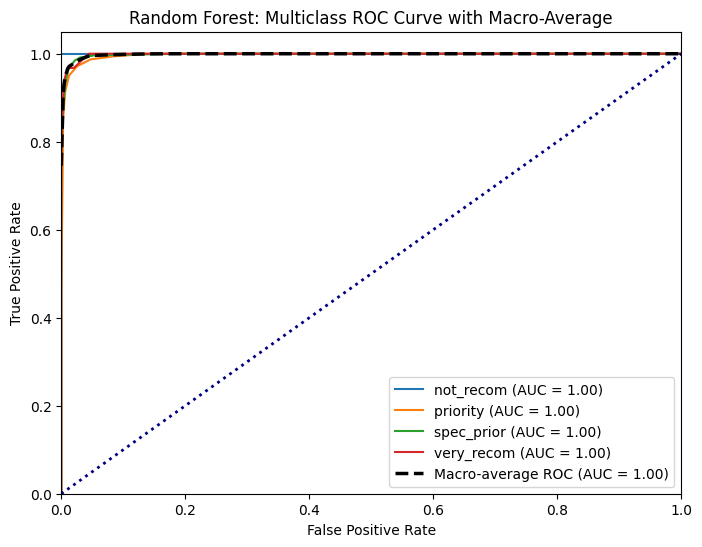

In [132]:
plt.figure(figsize=(8,6))

# Plot per-class ROC
for i, class_name in enumerate(classes):
    plt.plot(fpr_dict[i], tpr_dict[i], lw=1.5, label=f'{class_name} (AUC = {roc_auc_dict[i]:.2f})')

# Plot macro-average ROC
plt.plot(all_fpr, mean_tpr, color='black', lw=2.5, linestyle='--', label=f'Macro-average ROC (AUC = {roc_auc_macro:.2f})')

# Diagonal reference
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle=':')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest: Multiclass ROC Curve with Macro-Average')
plt.legend(loc='lower right')
plt.show()


### XGBoost

In [133]:
import xgboost as xgb

In [134]:
features = dv.get_feature_names_out().tolist() # call the method
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [135]:
xgb_params = {
    'eta' : 0.1,
    'max_depth': 3,
    'min_child_weight': 1,
    'objective' : 'multi:softprob',
    'num_class': 4,       # ✅ must be a string key
    'nthread': 8,
    'seed': 1,
    'verbosity': 1
}

model = xgb.XGBClassifier(xgb_params, dtrain)

/Users/rajibul/.local/share/virtualenvs/Midterm_Project-XzdtAkyc/lib/python3.11/site-packages/xgboost/core.py:771: FutureWarning: Pass `objective` as keyword args.
  warnings.warn(msg, FutureWarning)


In [136]:
model.fit(X_train, y_train)

,objective,'multi:softprob'
,kwargs,<xgboost.core...t 0x11fbaa850>
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False


In [137]:
# Predict labels
y_val_pred = model.predict(X_val)

# Classification report
print(classification_report(y_val, y_val_pred, target_names=classes))

# Predict probabilities for ROC-AUC
y_val_proba = model.predict_proba(X_val)
roc_auc = roc_auc_score(y_val, y_val_proba, multi_class='ovr', average='macro')
print("Macro ROC-AUC score:", roc_auc)


              precision    recall  f1-score   support

   not_recom       1.00      1.00      1.00       854
    priority       1.00      1.00      1.00       851
  spec_prior       1.00      1.00      1.00       825
  very_recom       1.00      1.00      1.00        62

    accuracy                           1.00      2592
   macro avg       1.00      1.00      1.00      2592
weighted avg       1.00      1.00      1.00      2592

Macro ROC-AUC score: 1.0


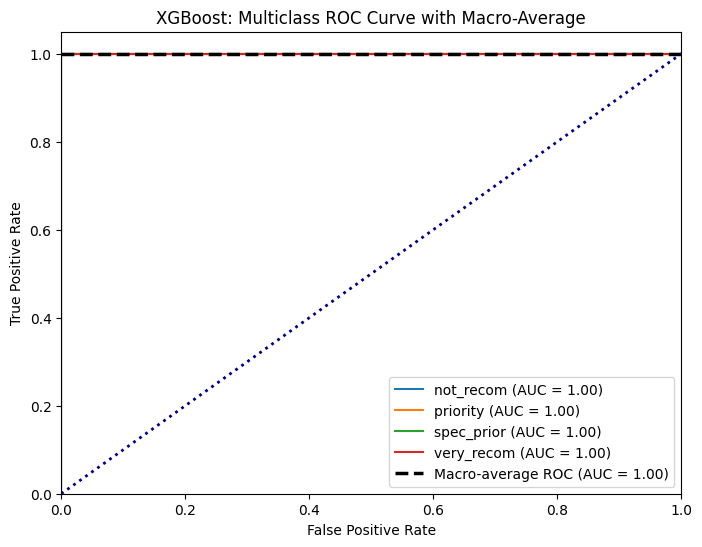

In [138]:
from sklearn.preprocessing import label_binarize

# Binarize labels
y_val_bin = label_binarize(y_val, classes=range(len(classes)))

fpr_dict = dict()
tpr_dict = dict()
roc_auc_dict = dict()

# Compute ROC per class
for i, class_name in enumerate(classes):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_val_bin[:, i], y_val_proba[:, i])
    roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

# Macro-average
all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(len(classes))]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(classes)):
    mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
mean_tpr /= len(classes)
roc_auc_macro = auc(all_fpr, mean_tpr)

# Plot
plt.figure(figsize=(8,6))
for i, class_name in enumerate(classes):
    plt.plot(fpr_dict[i], tpr_dict[i], lw=1.5, label=f'{class_name} (AUC = {roc_auc_dict[i]:.2f})')
plt.plot(all_fpr, mean_tpr, color='black', lw=2.5, linestyle='--', label=f'Macro-average ROC (AUC = {roc_auc_macro:.2f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle=':')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost: Multiclass ROC Curve with Macro-Average')
plt.legend(loc='lower right')
plt.show()


### Cross-validation

In [139]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)

In [140]:
# Use accuracy as metric (or f1_macro for multiclass balance)
scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1_macro')

print("F1 Macro scores for each fold:", scores)
print("Mean F1 Macro:", np.mean(scores))
print("Std deviation:", np.std(scores))

F1 Macro scores for each fold: [0.96758039 0.97844758 0.97129136 0.97428122 0.96078523]
Mean F1 Macro: 0.97047715570216
Std deviation: 0.006016412421580966
